<a href="https://colab.research.google.com/github/rijulcenat/Analisis-Performa-dan-Dominasi-Konstruktor-Formula-1/blob/main/Analisis_Performa_dan_Dominasi_Konstruktor_Formula_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


###Analisis Performa dan Dominasi Konstruktor Formula 1
Nama : Dhani Arizal Fauzan Adzima

NIM : 245150401111024

Kelas: Pengantar Sains Data - E

####**1. Instalasi dan Pengunduhan Data**

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Download dataset
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

print("Data berhasil diunduh di lokasi:", path)

# 2. List semua file yang ada di folder tersebut untuk memastikan namanya
print("Daftar file:", os.listdir(path))

Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Data berhasil diunduh di lokasi: /kaggle/input/formula-1-world-championship-1950-2020
Daftar file: ['races.csv', 'constructor_results.csv', 'drivers.csv', 'constructors.csv', 'lap_times.csv', 'status.csv', 'driver_standings.csv', 'seasons.csv', 'pit_stops.csv', 'sprint_results.csv', 'constructor_standings.csv', 'results.csv', 'circuits.csv', 'qualifying.csv']


In [ ]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLapSpeed,statusId,year,name_race,round,forename,surname,name_team,status,driver_name
0,1,18,1,1,22,1,1,1,1,10.0,...,218.300,1,2008,Australian Grand Prix,1,Lewis,Hamilton,McLaren,Finished,Lewis Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,217.586,1,2008,Australian Grand Prix,1,Nick,Heidfeld,BMW Sauber,Finished,Nick Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,216.719,1,2008,Australian Grand Prix,1,Nico,Rosberg,Williams,Finished,Nico Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,215.464,1,2008,Australian Grand Prix,1,Fernando,Alonso,Renault,Finished,Fernando Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,218.385,1,2008,Australian Grand Prix,1,Heikki,Kovalainen,McLaren,Finished,Heikki Kovalainen


####**2. Loading & Merging Data**

In [ ]:
# Membaca semua file CSV yang diperlukan
results = pd.read_csv(os.path.join(path, 'results.csv'))
races = pd.read_csv(os.path.join(path, 'races.csv'))
drivers = pd.read_csv(os.path.join(path, 'drivers.csv'))
constructors = pd.read_csv(os.path.join(path, 'constructors.csv'))
status = pd.read_csv(os.path.join(path, 'status.csv'))

# Penggabungan (Merging) Tabel
df = pd.merge(results, races[['raceId', 'year', 'name', 'round']], on='raceId')
df = pd.merge(df, drivers[['driverId', 'forename', 'surname']], on='driverId')
df = pd.merge(df, constructors[['constructorId', 'name']], on='constructorId', suffixes=('_race', '_team'))
df = pd.merge(df, status, on='statusId')

# Penyesuaian Kolom
df['driver_name'] = df['forename'] + ' ' + df['surname']
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')

# Filter Era Modern (2010 - Sekarang) untuk analisis yang relevan dengan tren saat ini
df_modern = df[df['year'] >= 2010].copy()
print("Data berhasil digabungkan dan siap dianalisis!")

Data berhasil digabungkan dan siap dianalisis!


Tahap awal ini melakukan Data Integration dari 5 sumber tabel relasional berbeda (results, races, drivers, constructors, dan status). Kita melakukan pembersihan data (data cleaning) dengan menyaring era modern (2010-sekarang) untuk memastikan hasil analisis relevan dengan regulasi mesin Turbo-Hybrid saat in

####**3. Analisis 1: Korelasi Posisi Start vs Finish (Performa)**

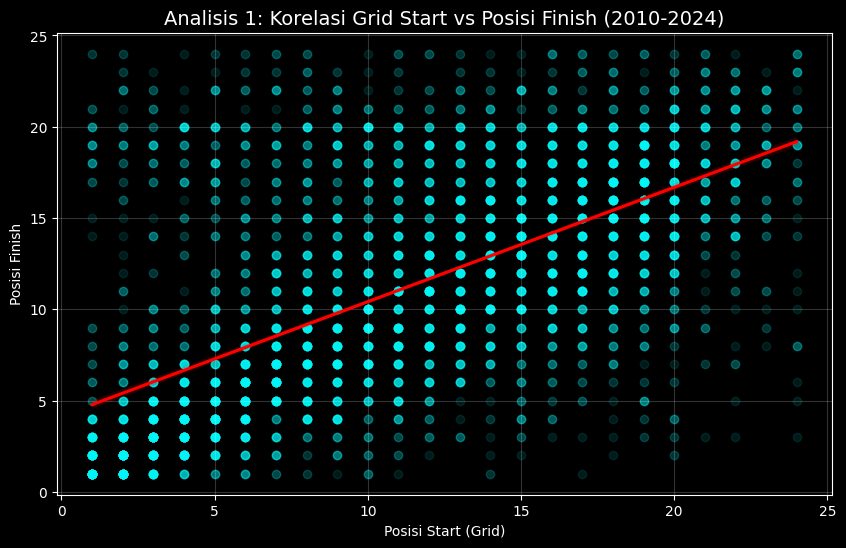

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_modern[df_modern['grid'] > 0], x='grid', y='positionOrder',
            scatter_kws={'alpha':0.1, 'color':'cyan'}, line_kws={'color':'red'})

plt.title('Analisis 1: Korelasi Grid Start vs Posisi Finish (2010-2024)', fontsize=14)
plt.xlabel('Posisi Start (Grid)')
plt.ylabel('Posisi Finish')
plt.grid(alpha=0.2)
plt.show()


**Insight Strategi:**
Grafik ini #menunjukkan adanya Korelasi Positif Kuat. Semakin rendah angka grid (start di depan), semakin rendah pula angka posisi finis.

**Temuan Utama:**
Di era modern, sesi kualifikasi pada hari Sabtu menyumbang persentase kesuksesan yang sangat besar. Hal ini disebabkan oleh desain aerodinamika mobil modern yang menghasilkan dirty air, sehingga sulit bagi pembalap di belakang untuk melakukan overtaking jika tidak memiliki selisih kecepatan yang signifikan.

####**4. Analisis 2: Dominasi Konstruktor (Bisnis & Market)**

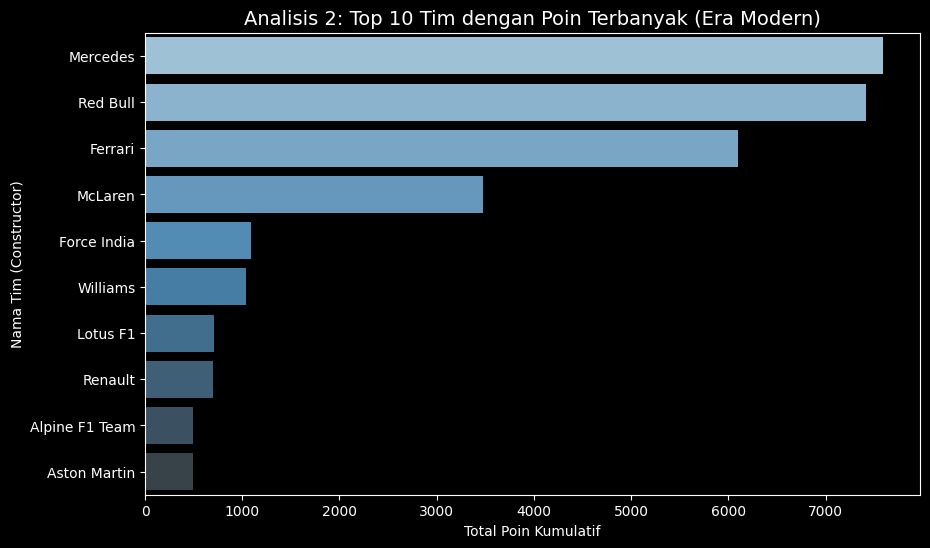

In [ ]:
# Menghitung total poin kumulatif per tim
top_teams = df_modern.groupby('name_team')['points'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_teams.values, y=top_teams.index, hue=top_teams.index, palette="Blues_d", legend=False)
plt.title('Analisis 2: Top 10 Tim dengan Poin Terbanyak (Era Modern)', fontsize=14)
plt.xlabel('Total Poin Kumulatif')
plt.ylabel('Nama Tim (Constructor)')
plt.show()

**Insight Bisnis:**
Grafik ini merepresentasikan Dominasi Kapital dan Teknologi dalam industri F1.

**Analisis Pasar:**
Tim seperti Mercedes, Red Bull, dan Ferrari menguasai mayoritas poin kumulatif. Ini menunjukkan bahwa kesuksesan di lintasan berbanding lurus dengan besarnya investasi pada departemen Research & Development (R&D). Bagi sebuah startup atau tim baru, menembus dominasi "Tiga Besar" ini memerlukan efisiensi biaya yang luar biasa di bawah aturan Budget Cap yang baru.

####**5. Analisis 3: The Comeback Kings (Strategi Overtaking)**

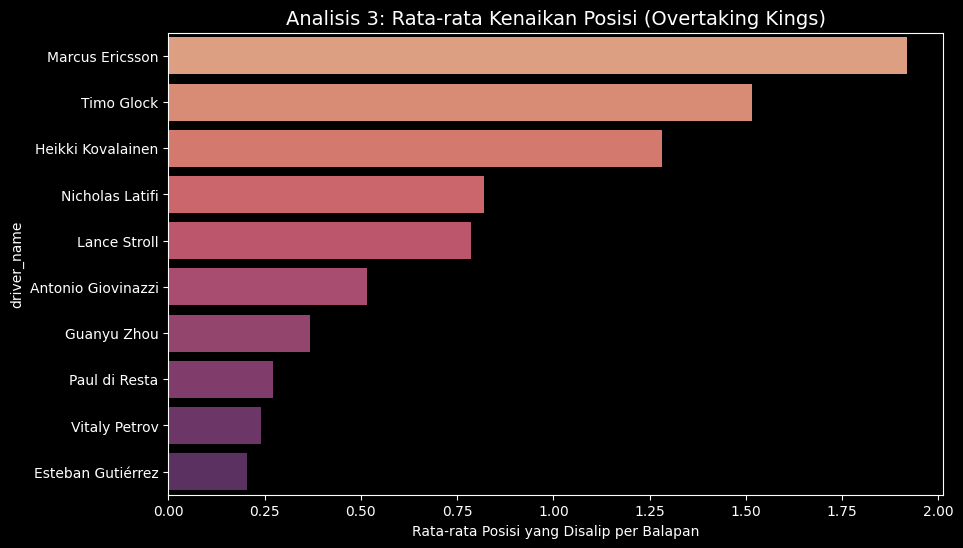

In [ ]:
# Menghitung selisih posisi (Posisi Start - Posisi Finish)
df_modern['pos_gain'] = df_modern['grid'] - df_modern['positionOrder']

# Rata-rata kenaikan posisi per pembalap (Min. 50 balapan agar data valid)
driver_stats = df_modern.groupby('driver_name').agg({'pos_gain': 'mean', 'raceId': 'count'})
top_overtakers = driver_stats[driver_stats['raceId'] > 50].sort_values(by='pos_gain', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_overtakers['pos_gain'], y=top_overtakers.index, hue=top_overtakers.index, palette="flare", legend=False)
plt.title('Analisis 3: Rata-rata Kenaikan Posisi (Overtaking Kings)', fontsize=14)
plt.xlabel('Rata-rata Posisi yang Disalip per Balapan')
plt.show()

**Insight Performa Individual:**
Analisis ini menyoroti pembalap yang memiliki kemampuan Adaptasi dan Strategi Balapan yang unggul.

**Kesimpulan:**
Pembalap dengan rata-rata kenaikan posisi tertinggi seringkali adalah mereka yang memiliki manajemen ban (tyre management) yang baik atau tim yang berani mengambil risiko strategi pit stop yang berbeda. Ini membuktikan bahwa meskipun kualifikasi itu penting, variabel manusia dan strategi tim tetap bisa mengubah hasil akhir secara dramatis.

####**6. Analisis 4: Reliability & Risk (Analisis DNF)**

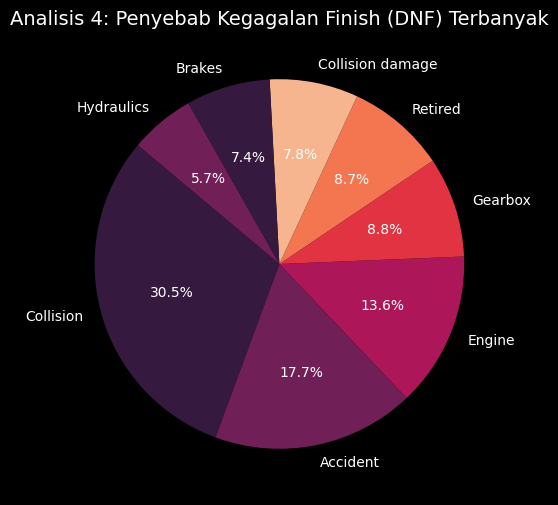

In [ ]:
# Filter data yang tidak finish (Status bukan 'Finished' atau bukan '+n Laps')
dnf_data = df_modern[~df_modern['status'].str.contains(r'Finished|\+', case=False)]
dnf_reasons = dnf_data['status'].value_counts().head(8)

plt.figure(figsize=(10, 6))
plt.pie(dnf_reasons, labels=dnf_reasons.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("rocket"))
plt.title('Analisis 4: Penyebab Kegagalan Finish (DNF) Terbanyak', fontsize=14)
plt.show()

**Insight Manajemen Risiko:**
Pie Chart ini memetakan penyebab utama kegagalan finis (Did Not Finish).

**Hasil Analisis:**
Menariknya, seiring berkembangnya teknologi, kegagalan mesin (Power Unit) kini mulai bersaing dengan insiden/tabrakan (Accident) sebagai penyebab utama DNF. Dari sudut pandang teknis, ini menunjukkan bahwa mendorong mesin hingga batas maksimal (extreme performance) membawa risiko reliabilitas yang tinggi. Bagi tim balap, menjaga keseimbangan antara kecepatan dan daya tahan mesin adalah kunci untuk memenangkan kejuaraan dunia.

###Executive Summary

Proyek Sains Data ini membuktikan bahwa Formula 1 adalah olahraga yang sangat Data-Driven. Melalui pengolahan dataset historis, kita dapat menyimpulkan bahwa kualifikasi adalah fondasi utama kemenangan, namun manajemen risiko teknis (DNF) dan strategi overtaking adalah variabel kritis yang menentukan konsistensi perolehan poin secara bisnis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    